# scitex_seizure_metrics — Detection (sample-based) Quick Start

Per-window classification metrics for seizure detection. One call to `scitex_seizure_metrics.detection.evaluate(...)` returns a `MetricsReport` carrying every metric the audit literature reaches for — AUROC, AUPRC, Brier, MCC, balanced accuracy, sensitivity, precision.

**What this notebook covers**

1. Build a synthetic per-window probability stream with realistic prevalence.
2. Score it with `detection.evaluate`.
3. Visualise the predictor's class-conditional histogram and the ROC + PR curves.

Companion notebooks:
- `02_forecasting_quick_start.ipynb` — alarm-based regime
- `04_calibration.ipynb` — Brier decomposition + reliability diagram
- `05_papers_andrade2024.ipynb` — sample-vs-alarm gap reproduction

---
**figrecipe drop-in note** — this notebook uses `figrecipe.subplots()` instead of `matplotlib.pyplot.subplots()`. figrecipe returns a `RecordingFigure` + `RecordingAxes` pair that proxies every standard matplotlib method, so every line below is a verbatim copy of the matplotlib version — no API changes — but the figure can now also be saved as a reproducible bundle via `fg.save(fig, 'recipe.zip')`.

In [1]:
%matplotlib inline
import warnings

warnings.filterwarnings('ignore', category=UserWarning)

import figrecipe as fg  # drop-in: returns RecordingFigure / RecordingAxes
import numpy as np
from sklearn.metrics import precision_recall_curve, roc_curve

import scitex_seizure_metrics
from scitex_seizure_metrics import detection

scitex_seizure_metrics.__version__

'0.1.0'

## 1. Synthetic per-window stream

5% positive rate matches typical pre-ictal vs inter-ictal class balance in published EEG / iEEG benchmarks. A modest-signal predictor lifts the positive class probability by ~0.4 above noise.

In [2]:
rng = np.random.default_rng(0)
n = 1000
y_true = (rng.uniform(0, 1, n) < 0.05).astype(int)
y_proba = np.clip(0.4 * y_true + rng.normal(0.3, 0.15, n), 0, 1)

print(f'n_windows  : {n}')
print(f'positives  : {y_true.sum()} ({y_true.mean():.1%})')
print(f'mean proba : {y_proba.mean():.3f}')

n_windows  : 1000
positives  : 45 (4.5%)
mean proba : 0.318


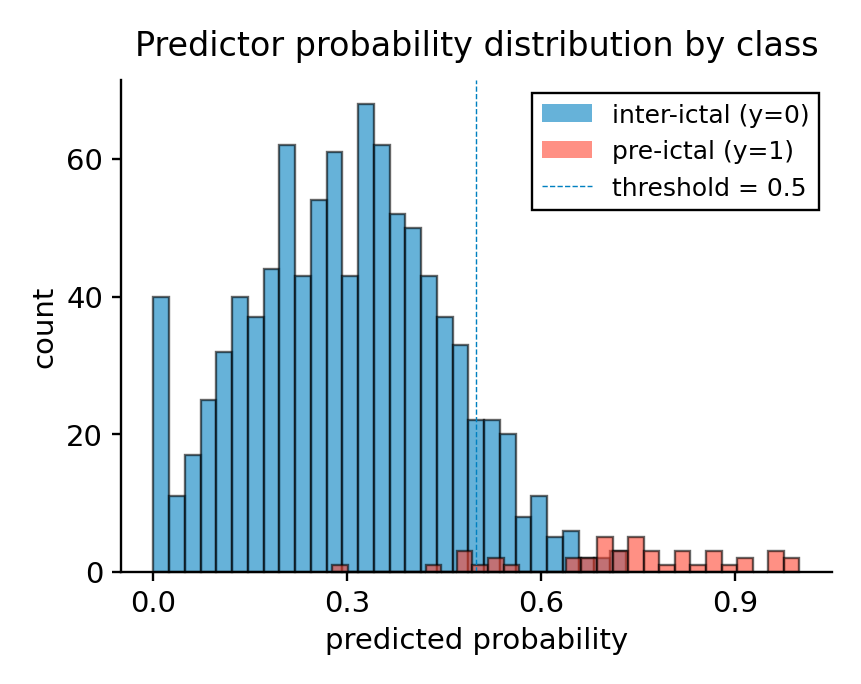

In [3]:
# Predictor distribution by class — see the separation visually
fig, ax = fg.subplots()
ax.hist(y_proba[y_true == 0], bins=30, alpha=0.6, label='inter-ictal (y=0)')
ax.hist(y_proba[y_true == 1], bins=30, alpha=0.6, label='pre-ictal (y=1)')
ax.axvline(0.5, linestyle='--', label='threshold = 0.5')
ax.set_xlabel('predicted probability')
ax.set_ylabel('count')
ax.set_title('Predictor probability distribution by class')
ax.legend()


## 2. Evaluate

`detection.evaluate` returns a `MetricsReport` with everything pre-computed. `threshold` is the binarisation point used for sensitivity / precision / MCC; `fs` is the sample-rate (1 Hz here).

In [4]:
rep = detection.evaluate(
    y_true, y_proba,
    threshold=0.5, fs=1,
    name='quick_start',
)
rep.to_frame().T

,0
name,quick_start
regime,detection
roc_auc,0.968889
pr_auc,0.827581
brier,0.110706
balanced_accuracy,0.897848
mcc,0.492097
sensitivity,0.888889
precision,0.310078
f1,0.45977


In [5]:
print(f'AUROC              : {rep.roc_auc:.3f}')
print(f'AUPRC              : {rep.pr_auc:.3f}')
print(f'Brier              : {rep.brier:.3f}')
print(f'MCC                : {rep.mcc:.3f}')
print(f'balanced accuracy  : {rep.balanced_accuracy:.3f}')
print(f'sensitivity        : {rep.sensitivity:.3f}')
print(f'precision          : {rep.precision:.3f}')

AUROC              : 0.969
AUPRC              : 0.828
Brier              : 0.111
MCC                : 0.492
balanced accuracy  : 0.898
sensitivity        : 0.889
precision          : 0.310


## 3. ROC + PR curves

AUROC and AUPRC are summary scalars; the curves themselves expose where the predictor concentrates its operating points. PR is the one to read on imbalanced data — AUROC at 5% prevalence can look optimistic.

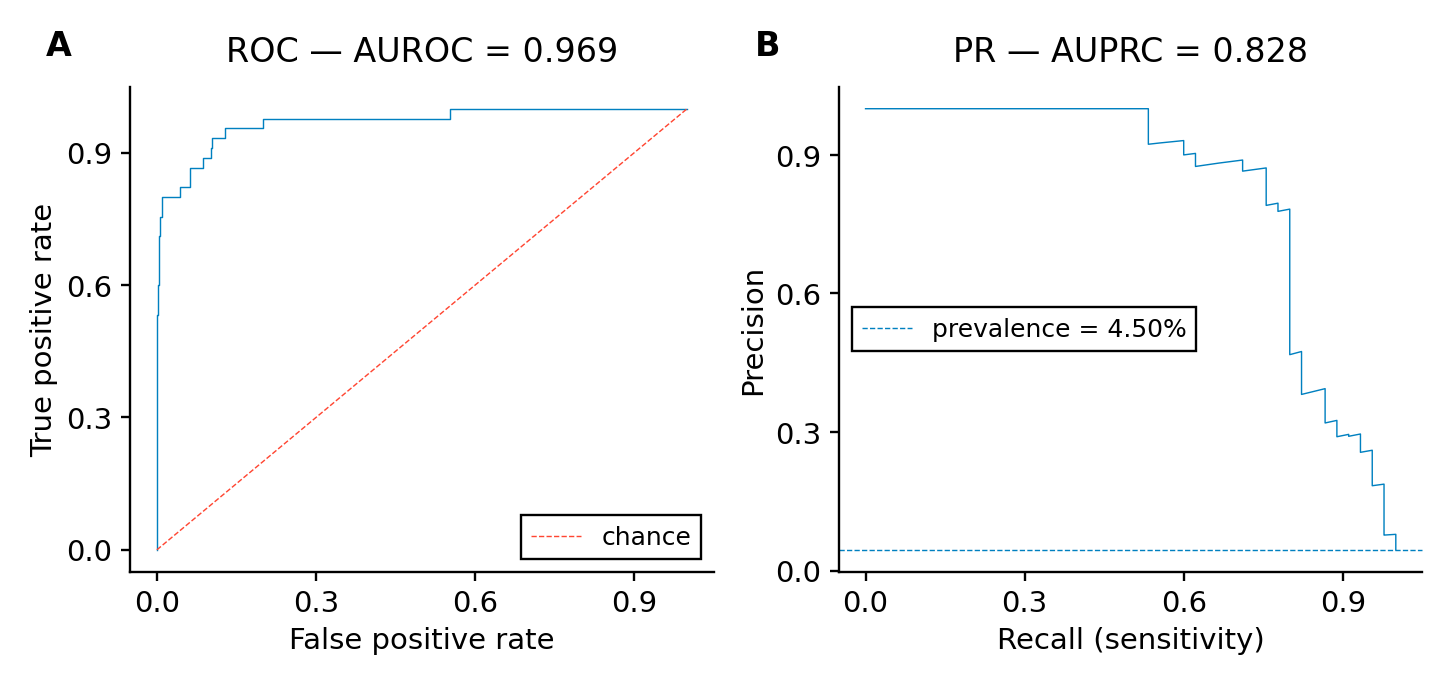

In [6]:
fpr, tpr, _ = roc_curve(y_true, y_proba)
prec, rec, _ = precision_recall_curve(y_true, y_proba)

fig, axes = fg.subplots(1, 2)
axes[0].plot(fpr, tpr)
axes[0].plot([0, 1], [0, 1], '--', label='chance')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].set_title(f'ROC — AUROC = {rep.roc_auc:.3f}')
axes[0].legend()

axes[1].plot(rec, prec)
axes[1].axhline(y_true.mean(), linestyle='--',
                label=f'prevalence = {y_true.mean():.2%}')
axes[1].set_xlabel('Recall (sensitivity)')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'PR — AUPRC = {rep.pr_auc:.3f}')
axes[1].legend()



## Where to next

- **`02_forecasting_quick_start.ipynb`** — alarm-based regime with `AlarmPolicy`, sensitivity / FP-per-hour / IoC.
- **`03_bridge_sample_to_alarm.ipynb`** — analytic conversion bounds when only one regime was published.
- **`04_calibration.ipynb`** — Brier decomposition, reliability diagram, ECE.
- **`05_papers_andrade2024.ipynb`** — paper-replica showing the sample-vs-alarm regime gap.